# Train Data Analysis

Analyze the length distribution of the current prechunked training dataset and save plots under `analysis/img/`.

In [4]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from statistics import median

import matplotlib.pyplot as plt
from IPython.display import Image, display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing pyproject.toml")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pretrain.data import LmxDataConfig, LmxTrainDataset

In [5]:
@dataclass(frozen=True, slots=True)
class ChunkProfile:
    label: str
    data_config: LmxDataConfig


def collect_chunk_lengths(config: LmxDataConfig) -> list[int]:
    dataset = LmxTrainDataset(config)
    return [dataset.sequence_length(index) for index in range(len(dataset))]


def summarize_chunk_lengths(lengths: list[int]) -> dict[str, float | int]:
    if not lengths:
        raise ValueError("lengths must not be empty.")
    ordered = sorted(lengths)
    p90_index = min(len(ordered) - 1, max(0, int(len(ordered) * 0.9 + 0.999999) - 1))
    return {
        "count": len(ordered),
        "avg": sum(ordered) / len(ordered),
        "median": float(median(ordered)),
        "p90": int(ordered[p90_index]),
        "max": int(ordered[-1]),
    }


def plot_chunk_length_distributions(
    profiles: list[ChunkProfile],
    *,
    output_image_path: str | Path,
) -> dict[str, dict[str, float | int]]:
    if not profiles:
        raise ValueError("profiles must not be empty.")

    output_image_path = Path(output_image_path)
    output_image_path.parent.mkdir(parents=True, exist_ok=True)

    length_sets: dict[str, list[int]] = {}
    summaries: dict[str, dict[str, float | int]] = {}
    max_length = 0
    for profile in profiles:
        lengths = collect_chunk_lengths(profile.data_config)
        length_sets[profile.label] = lengths
        summaries[profile.label] = summarize_chunk_lengths(lengths)
        max_length = max(max_length, max(lengths))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    bins = min(80, max(20, max_length // 16))

    for label, lengths in length_sets.items():
        axes[0].hist(lengths, bins=bins, density=True, alpha=0.45, label=label)

        ordered = sorted(lengths)
        cumulative = [(index + 1) / len(ordered) for index in range(len(ordered))]
        axes[1].plot(ordered, cumulative, label=label)

    axes[0].set_title("Chunk Length Density")
    axes[0].set_xlabel("Chunk length")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    axes[1].set_title("Chunk Length CDF")
    axes[1].set_xlabel("Chunk length")
    axes[1].set_ylabel("Cumulative ratio")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(output_image_path, dpi=180)
    plt.close(fig)
    return summaries


def build_current_train_profiles() -> list[ChunkProfile]:
    return [
        ChunkProfile(
            label="bar_aware_overlap2_recommended",
            data_config=LmxDataConfig(
                dataset_path="data/bar_aware_chunk/training_bar_chunk_encoded_overlap2_full_dataset",
                split="training",
                max_length=1024,
                length_bucketing=True,
                bucket_padding_noise=0.0,
                max_tokens_per_batch=16384,
                pad_to_length_multiple=64,
                num_workers=0,
            ),
        ),
    ]

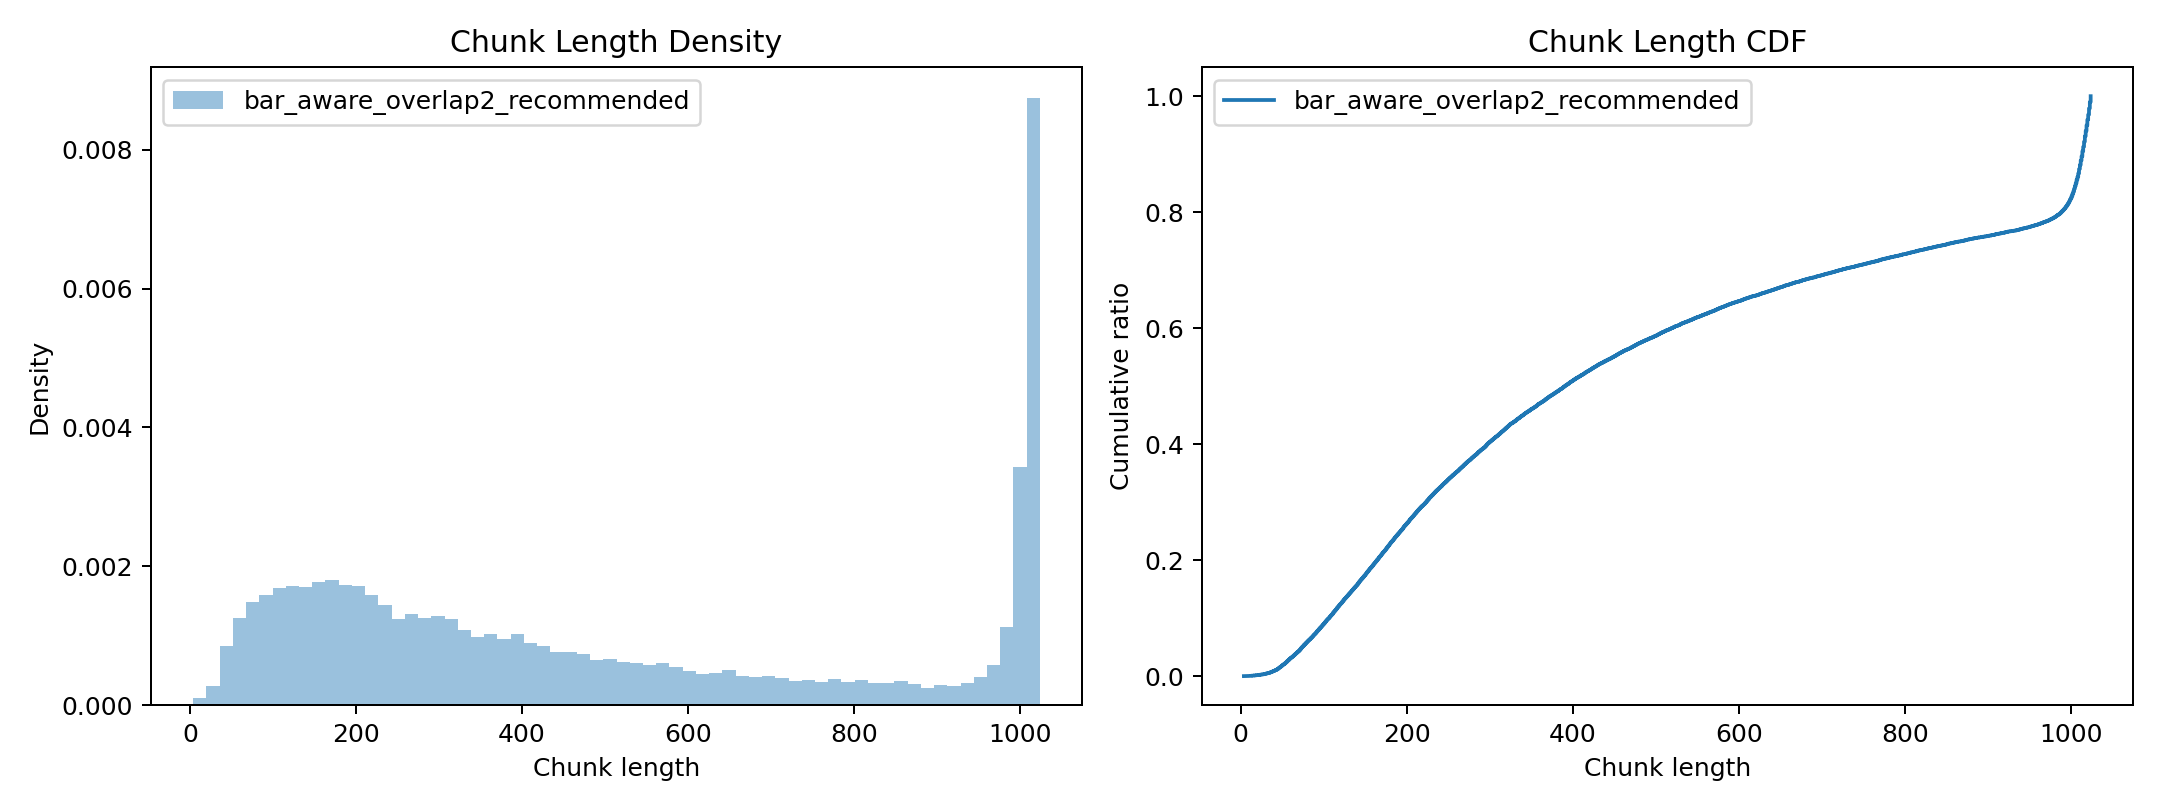

len == 1024 ratio: 1.0059%
len >= 1000 ratio: 17.8367%


{'bar_aware_overlap2_recommended': {'count': 37378,
  'avg': 495.7168655358767,
  'median': 391.0,
  'p90': 1014,
  'max': 1024}}

In [6]:
OUTPUT_IMAGE_PATH = Path("analysis/img/current_train_chunk_length_distribution.png")
profiles = build_current_train_profiles()

summaries = plot_chunk_length_distributions(
    profiles,
    output_image_path=OUTPUT_IMAGE_PATH,
)

primary_lengths = collect_chunk_lengths(profiles[0].data_config)
count = len(primary_lengths)
ratio_eq_1024 = sum(length == 1024 for length in primary_lengths) / count
ratio_ge_1000 = sum(length >= 1000 for length in primary_lengths) / count

display(Image(filename=str(OUTPUT_IMAGE_PATH)))
print(f"len == 1024 ratio: {ratio_eq_1024:.4%}")
print(f"len >= 1000 ratio: {ratio_ge_1000:.4%}")
summaries